Week 17 · Day 3 — Deep Convolutional GAN (DCGAN)
Why this matters

Fully-connected GANs can generate digits, but they struggle with textures and structure.
DCGANs add convolutional layers — enabling realistic images with spatial coherence.

Theory Essentials

ConvTranspose2d: upsampling (reverse convolution) to grow image size.

BatchNorm: stabilizes training, smooths gradients.

LeakyReLU: avoids dead neurons (better gradient flow).

DCGAN architecture tips:

Replace pooling with strided convs / transposed convs.

Use BatchNorm in both G and D (except output).

Avoid fully-connected layers.

100%|██████████| 170498071/170498071 [00:57<00:00, 2989323.84it/s]


Extracting data\cifar-10-python.tar.gz to data
Epoch 1: Loss_D=0.382, Loss_G=3.895
Epoch 2: Loss_D=0.463, Loss_G=3.128
Epoch 3: Loss_D=0.495, Loss_G=2.302
Epoch 4: Loss_D=0.571, Loss_G=4.550
Epoch 5: Loss_D=0.959, Loss_G=5.810


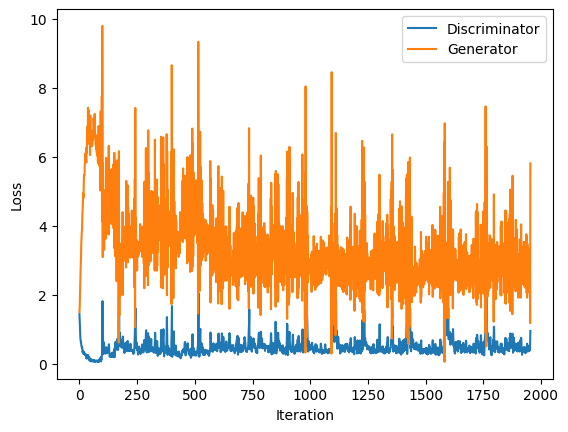

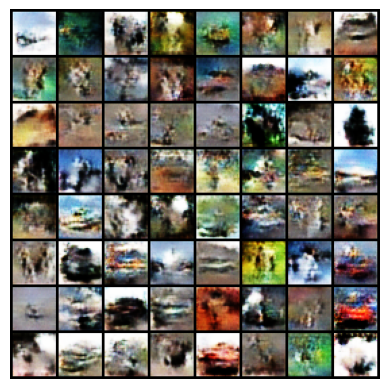

In [1]:
# Setup
import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
latent_dim = 100

# Data (CIFAR-10 subset)
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
dataset = datasets.CIFAR10(root="data", train=True, transform=transform, download=True)
loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

# --- Generator ---
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z): return self.net(z)

# --- Discriminator ---
class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x).view(-1, 1).squeeze(1)

G, D = DCGenerator(latent_dim).to(device), DCDiscriminator().to(device)
opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

losses_G, losses_D = [], []

# --- Training ---
for epoch in range(5):
    for real, _ in loader:
        real = real.to(device)
        bsz = real.size(0)

        # Labels
        real_labels = torch.ones(bsz, device=device)
        fake_labels = torch.zeros(bsz, device=device)

        # --- Train D ---
        z = torch.randn(bsz, latent_dim, 1, 1, device=device)
        fake = G(z)
        D_real = D(real)
        D_fake = D(fake.detach())
        loss_D = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # --- Train G ---
        D_fake = D(fake)
        loss_G = criterion(D_fake, real_labels)
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

        losses_D.append(loss_D.item())
        losses_G.append(loss_G.item())

    print(f"Epoch {epoch+1}: Loss_D={loss_D.item():.3f}, Loss_G={loss_G.item():.3f}")

# --- Visualize ---
plt.figure()
plt.plot(losses_D, label="Discriminator")
plt.plot(losses_G, label="Generator")
plt.legend(); plt.xlabel("Iteration"); plt.ylabel("Loss"); plt.show()

# Generate sample grid
with torch.no_grad():
    z = torch.randn(64, latent_dim, 1, 1, device=device)
    samples = (G(z).cpu() + 1) / 2
    grid = utils.make_grid(samples, nrow=8)
plt.imshow(grid.permute(1, 2, 0)); plt.axis("off"); plt.show()


changed the code a little bit so it runs faster on cpu

Files already downloaded and verified


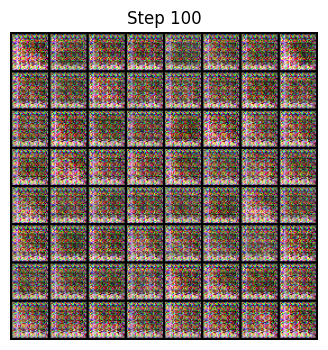

Epoch 1: Loss_D=0.698 | Loss_G=4.023


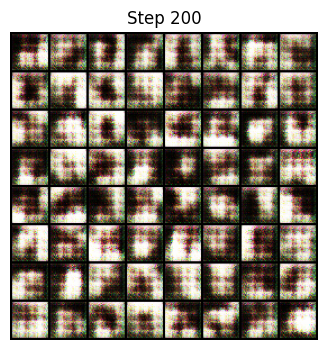

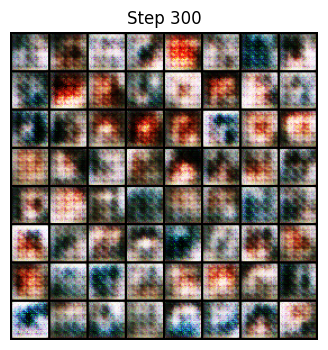

Epoch 2: Loss_D=0.629 | Loss_G=3.069


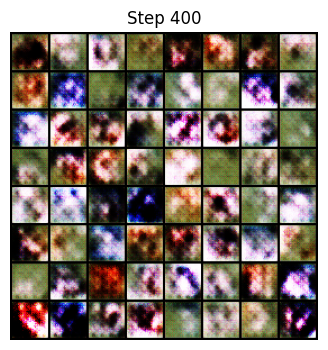

Epoch 3: Loss_D=0.531 | Loss_G=3.579


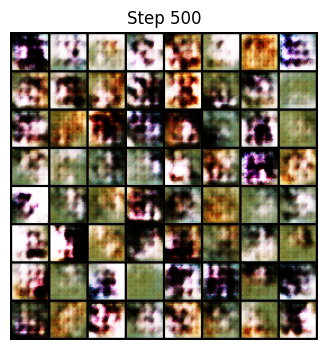

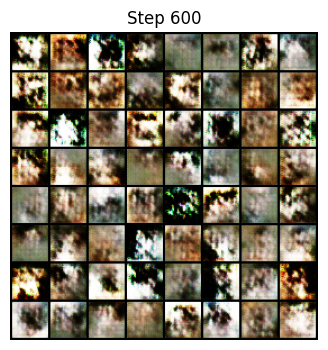

Epoch 4: Loss_D=0.570 | Loss_G=3.375


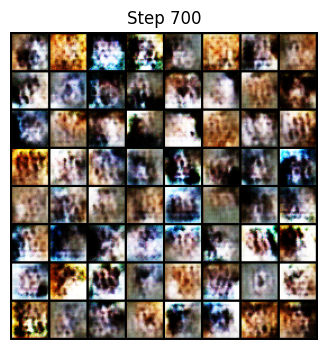

Epoch 5: Loss_D=0.771 | Loss_G=2.776


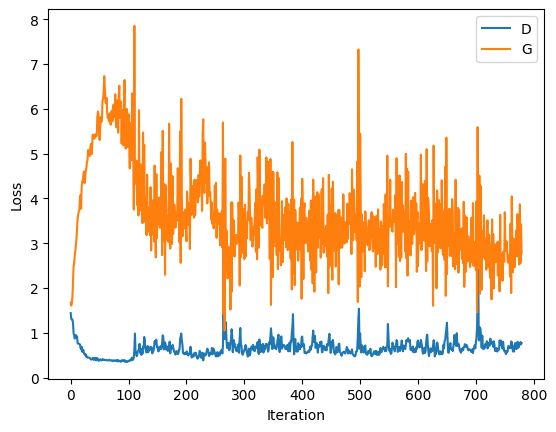

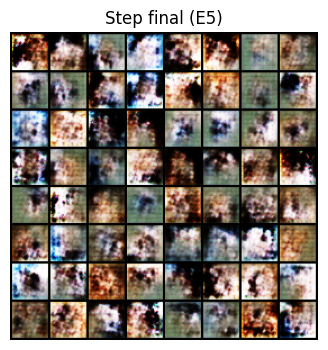

In [ ]:
# ---- DCGAN (Balanced CPU Preset: 5–10 min) ----
import os, numpy as np, torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ===== Target runtime knobs =====
CLASSES = ["cat", "dog"]           # pick 1–3 classes; 2 often gives clearer shapes
BATCH_SIZE = 64                    # 64 is CPU-friendly; use 128 if you can
MAX_SAMPLES_PER_CLASS = 6000       # cap per class (2×6000 ≈ 12k)
MAX_BATCHES_PER_EPOCH = 300        # 200–500; raise/lower to hit 5–10 min
EPOCHS = 5
Z_DIM = 64
BASE = 64                          # 64 is a good balance (32 is faster but blurrier)
PREVIEW_EVERY = 100                # show grid every N iters

# ===== Data (CIFAR-10, RGB 32×32, select classes) =====
CLASS_TO_IDX = {"airplane":0,"automobile":1,"bird":2,"cat":3,"deer":4,
                "dog":5,"frog":6,"horse":7,"ship":8,"truck":9}
target_ids = {CLASS_TO_IDX[c] for c in CLASSES}

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
full = datasets.CIFAR10("data", train=True, download=True, transform=transform)

# filter + cap per class
per_class = {i:0 for i in target_ids}
idxs = []
for i, (_, y) in enumerate(full):
    if y in target_ids and per_class[y] < MAX_SAMPLES_PER_CLASS:
        idxs.append(i); per_class[y]+=1
dataset = Subset(full, idxs)

# num_workers=0 is often fastest on Windows CPU; try 2 on Linux
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)

# ===== Models =====
class G(nn.Module):
    # z: (bs, Z_DIM,1,1) -> (bs,3,32,32)
    def __init__(self, z=Z_DIM, base=BASE):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z, base*4, 4, 1, 0, bias=False),   # 1->4
            nn.BatchNorm2d(base*4), nn.ReLU(True),
            nn.ConvTranspose2d(base*4, base*2, 4, 2, 1, bias=False), # 4->8
            nn.BatchNorm2d(base*2), nn.ReLU(True),
            nn.ConvTranspose2d(base*2, base,   4, 2, 1, bias=False), # 8->16
            nn.BatchNorm2d(base),   nn.ReLU(True),
            nn.ConvTranspose2d(base, 3,         4, 2, 1, bias=False), # 16->32
            nn.Tanh()
        )
    def forward(self, z): return self.net(z)

class D(nn.Module):
    # returns logits
    def __init__(self, base=BASE):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, base,   4, 2, 1, bias=False),            # 32->16
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base, base*2, 4, 2, 1, bias=False),         # 16->8
            nn.BatchNorm2d(base*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base*2, base*4, 4, 2, 1, bias=False),       # 8->4
            nn.BatchNorm2d(base*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base*4, 1, 4, 1, 0, bias=False)             # 4->1
        )
    def forward(self, x): return self.net(x).view(-1)

G, D = G().to(device), D().to(device)

# Optional compile (PyTorch 2.x); safe to skip if it errors
try:
    G = torch.compile(G, mode="reduce-overhead")
    D = torch.compile(D, mode="reduce-overhead")
except Exception:
    pass

opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

losses_G, losses_D = [], []

def preview(step):
    with torch.no_grad():
        z = torch.randn(64, Z_DIM, 1, 1, device=device)
        samples = (G(z).cpu()+1)/2
        grid = utils.make_grid(samples, nrow=8)
    plt.figure(figsize=(4,4))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off"); plt.title(f"Step {step}")
    plt.show()

global_step = 0
for epoch in range(EPOCHS):
    for i, (real, _) in enumerate(loader):
        if MAX_BATCHES_PER_EPOCH and i >= MAX_BATCHES_PER_EPOCH: break

        real = real.to(device)
        bsz  = real.size(0)
        # label smoothing for real: 0.9 instead of 1.0 helps stabilize on CPU
        real_y = torch.full((bsz,), 0.9, device=device)
        fake_y = torch.zeros(bsz, device=device)

        # --- Train D ---
        z = torch.randn(bsz, Z_DIM, 1, 1, device=device)
        with torch.no_grad():
            fake = G(z)
        d_real = D(real)
        d_fake = D(fake)
        loss_D = criterion(d_real, real_y) + criterion(d_fake, fake_y)
        opt_D.zero_grad(set_to_none=True); loss_D.backward(); opt_D.step()

        # --- Train G ---
        z = torch.randn(bsz, Z_DIM, 1, 1, device=device)
        fake = G(z)
        # want D(fake)=1; use 1.0 target for stronger signal
        loss_G = criterion(D(fake), torch.ones(bsz, device=device))
        opt_G.zero_grad(set_to_none=True); loss_G.backward(); opt_G.step()

        losses_D.append(loss_D.item()); losses_G.append(loss_G.item())
        global_step += 1

    print(f"Epoch {epoch+1}: Loss_D={loss_D.item():.3f} | Loss_G={loss_G.item():.3f}")

# Final curves
plt.figure(); plt.plot(losses_D, label="D"); plt.plot(losses_G, label="G")
plt.legend(); plt.xlabel("Iteration"); plt.ylabel("Loss"); plt.show()

# Final grid
preview(f"final (E{EPOCHS})")


1) Core (10–15 min)
Task: Change batch size from 128 → 64 and note effect on training stability.

New training looks more stable

2) Practice (15 min)
Task: Add nn.Dropout(0.3) in the discriminator layers.

Files already downloaded and verified
Epoch 1: Loss_D=0.820 | Loss_G=3.041
Epoch 2: Loss_D=1.070 | Loss_G=3.165
Epoch 3: Loss_D=0.791 | Loss_G=2.455
Epoch 4: Loss_D=0.982 | Loss_G=1.857
Epoch 5: Loss_D=1.082 | Loss_G=2.741


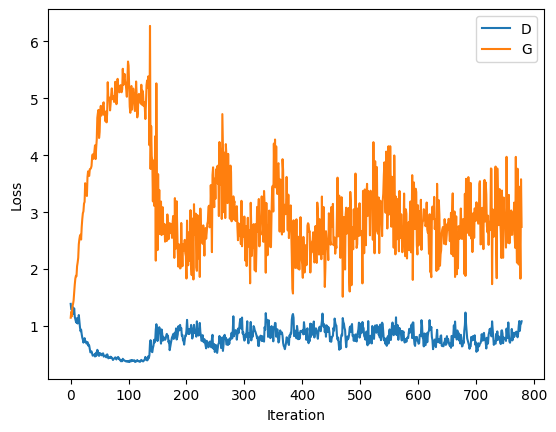

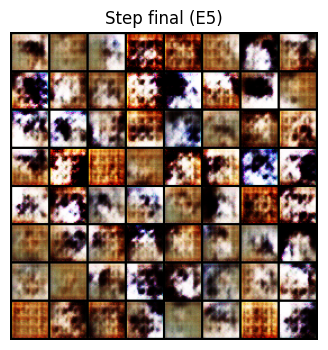

In [5]:
# ---- DCGAN (Balanced CPU Preset: 5–10 min, with Dropout) ----
import os, numpy as np, torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ===== Target runtime knobs =====
CLASSES = ["cat", "dog"]
BATCH_SIZE = 64
MAX_SAMPLES_PER_CLASS = 6000
MAX_BATCHES_PER_EPOCH = 300
EPOCHS = 5
Z_DIM = 64
BASE = 64
PREVIEW_EVERY = 100

# ===== Data =====
CLASS_TO_IDX = {"airplane":0,"automobile":1,"bird":2,"cat":3,"deer":4,
                "dog":5,"frog":6,"horse":7,"ship":8,"truck":9}
target_ids = {CLASS_TO_IDX[c] for c in CLASSES}

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
full = datasets.CIFAR10("data", train=True, download=True, transform=transform)

per_class = {i:0 for i in target_ids}
idxs = []
for i, (_, y) in enumerate(full):
    if y in target_ids and per_class[y] < MAX_SAMPLES_PER_CLASS:
        idxs.append(i); per_class[y]+=1
dataset = Subset(full, idxs)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)

# ===== Models =====
class G(nn.Module):
    def __init__(self, z=Z_DIM, base=BASE):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z, base*4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base*4), nn.ReLU(True),
            nn.ConvTranspose2d(base*4, base*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*2), nn.ReLU(True),
            nn.ConvTranspose2d(base*2, base, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base), nn.ReLU(True),
            nn.ConvTranspose2d(base, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z): return self.net(z)

class D(nn.Module):
    def __init__(self, base=BASE):
        super().__init__()
        self.net = nn.Sequential(
            # 32 -> 16
            nn.Conv2d(3, base, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            # 16 -> 8
            nn.Conv2d(base, base*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            # 8 -> 4
            nn.Conv2d(base*2, base*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            # 4 -> 1
            nn.Conv2d(base*4, 1, 4, 1, 0, bias=False)
        )
    def forward(self, x): return self.net(x).view(-1)

G, D = G().to(device), D().to(device)

# Optional compile (PyTorch 2.x)
try:
    G = torch.compile(G, mode="reduce-overhead")
    D = torch.compile(D, mode="reduce-overhead")
except Exception:
    pass

opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

losses_G, losses_D = [], []

def preview(step):
    with torch.no_grad():
        z = torch.randn(64, Z_DIM, 1, 1, device=device)
        samples = (G(z).cpu()+1)/2
        grid = utils.make_grid(samples, nrow=8)
    plt.figure(figsize=(4,4))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off"); plt.title(f"Step {step}")
    plt.show()

global_step = 0
for epoch in range(EPOCHS):
    for i, (real, _) in enumerate(loader):
        if MAX_BATCHES_PER_EPOCH and i >= MAX_BATCHES_PER_EPOCH: break

        real = real.to(device)
        bsz  = real.size(0)
        real_y = torch.full((bsz,), 0.9, device=device)
        fake_y = torch.zeros(bsz, device=device)

        # --- Train D ---
        z = torch.randn(bsz, Z_DIM, 1, 1, device=device)
        with torch.no_grad():
            fake = G(z)
        d_real = D(real)
        d_fake = D(fake)
        loss_D = criterion(d_real, real_y) + criterion(d_fake, fake_y)
        opt_D.zero_grad(set_to_none=True); loss_D.backward(); opt_D.step()

        # --- Train G ---
        z = torch.randn(bsz, Z_DIM, 1, 1, device=device)
        fake = G(z)
        loss_G = criterion(D(fake), torch.ones(bsz, device=device))
        opt_G.zero_grad(set_to_none=True); loss_G.backward(); opt_G.step()

        losses_D.append(loss_D.item()); losses_G.append(loss_G.item())
        global_step += 1

    print(f"Epoch {epoch+1}: Loss_D={loss_D.item():.3f} | Loss_G={loss_G.item():.3f}")

# Final curves
plt.figure(); plt.plot(losses_D, label="D"); plt.plot(losses_G, label="G")
plt.legend(); plt.xlabel("Iteration"); plt.ylabel("Loss"); plt.show()

# Final grid
preview(f"final (E{EPOCHS})")


3) Stretch (optional)
Task: Replace ReLU in the generator with LeakyReLU(0.2).



| Activation                       | Formula                                                           | Behavior                                                              |
| -------------------------------- | ----------------------------------------------------------------- | --------------------------------------------------------------------- |
| **ReLU** (Rectified Linear Unit) | ( f(x) = \max(0, x) )                                             | All negative values become 0 → neuron “shuts off”.                    |
| **LeakyReLU(α)**                 | ( f(x) = x ) if ( x>0 ), else ( f(x) = \alpha x ) (usually α=0.2) | Keeps a *small* slope for negatives, so neuron still passes gradient. |

### 🔍 Intuition

* **ReLU:**
  If a neuron’s input becomes negative, its output is 0 and its gradient is 0 → it *stops learning*.
  This can cause “dead neurons,” especially in GAN generators that already struggle with unstable gradients.

* **LeakyReLU:**
  Keeps a small negative slope (e.g., 0.2 × x). That means even when the input is negative, a *tiny gradient still flows back*.
  → helps **gradient flow**, avoids neurons dying, and can make GANs converge more smoothly.

### 🧠 TL;DR

| Case                              | Preferred                                  |
| --------------------------------- | ------------------------------------------ |
| Classifiers, CNNs                 | ReLU (simple and fast)                     |
| GANs, deep nets that can collapse | **LeakyReLU(0.2)** (keeps gradients alive) |

So, by switching to `LeakyReLU(0.2)` in your generator, you’re making it a bit more robust against vanishing gradients — especially useful when training on CPU or small datasets where updates are noisier.


Files already downloaded and verified
Epoch 1: Loss_D=1.082 | Loss_G=3.069
Epoch 2: Loss_D=0.724 | Loss_G=2.184
Epoch 3: Loss_D=0.829 | Loss_G=2.620
Epoch 4: Loss_D=0.908 | Loss_G=1.818
Epoch 5: Loss_D=1.167 | Loss_G=1.875


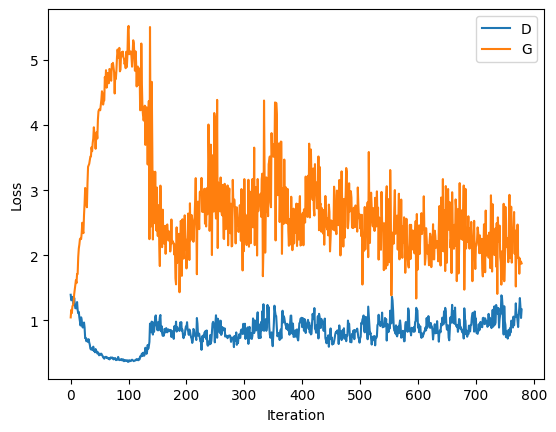

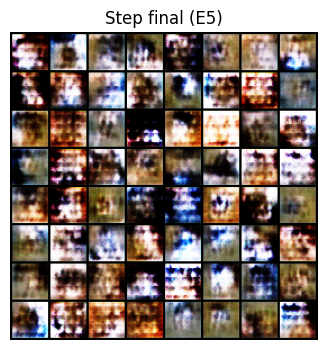

In [6]:
# ---- DCGAN (Balanced CPU Preset: 5–10 min, with Dropout) ----
import os, numpy as np, torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ===== Target runtime knobs =====
CLASSES = ["cat", "dog"]
BATCH_SIZE = 64
MAX_SAMPLES_PER_CLASS = 6000
MAX_BATCHES_PER_EPOCH = 300
EPOCHS = 5
Z_DIM = 64
BASE = 64
PREVIEW_EVERY = 100

# ===== Data =====
CLASS_TO_IDX = {"airplane":0,"automobile":1,"bird":2,"cat":3,"deer":4,
                "dog":5,"frog":6,"horse":7,"ship":8,"truck":9}
target_ids = {CLASS_TO_IDX[c] for c in CLASSES}

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
full = datasets.CIFAR10("data", train=True, download=True, transform=transform)

per_class = {i:0 for i in target_ids}
idxs = []
for i, (_, y) in enumerate(full):
    if y in target_ids and per_class[y] < MAX_SAMPLES_PER_CLASS:
        idxs.append(i); per_class[y]+=1
dataset = Subset(full, idxs)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)

# ===== Models =====
class G(nn.Module):
    def __init__(self, z=Z_DIM, base=BASE):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z, base*4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base*4), nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(base*4, base*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*2), nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(base*2, base, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base), nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(base, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z): return self.net(z)

class D(nn.Module):
    def __init__(self, base=BASE):
        super().__init__()
        self.net = nn.Sequential(
            # 32 -> 16
            nn.Conv2d(3, base, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            # 16 -> 8
            nn.Conv2d(base, base*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            # 8 -> 4
            nn.Conv2d(base*2, base*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            # 4 -> 1
            nn.Conv2d(base*4, 1, 4, 1, 0, bias=False)
        )
    def forward(self, x): return self.net(x).view(-1)

G, D = G().to(device), D().to(device)

# Optional compile (PyTorch 2.x)
try:
    G = torch.compile(G, mode="reduce-overhead")
    D = torch.compile(D, mode="reduce-overhead")
except Exception:
    pass

opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

losses_G, losses_D = [], []

def preview(step):
    with torch.no_grad():
        z = torch.randn(64, Z_DIM, 1, 1, device=device)
        samples = (G(z).cpu()+1)/2
        grid = utils.make_grid(samples, nrow=8)
    plt.figure(figsize=(4,4))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off"); plt.title(f"Step {step}")
    plt.show()

global_step = 0
for epoch in range(EPOCHS):
    for i, (real, _) in enumerate(loader):
        if MAX_BATCHES_PER_EPOCH and i >= MAX_BATCHES_PER_EPOCH: break

        real = real.to(device)
        bsz  = real.size(0)
        real_y = torch.full((bsz,), 0.9, device=device)
        fake_y = torch.zeros(bsz, device=device)

        # --- Train D ---
        z = torch.randn(bsz, Z_DIM, 1, 1, device=device)
        with torch.no_grad():
            fake = G(z)
        d_real = D(real)
        d_fake = D(fake)
        loss_D = criterion(d_real, real_y) + criterion(d_fake, fake_y)
        opt_D.zero_grad(set_to_none=True); loss_D.backward(); opt_D.step()

        # --- Train G ---
        z = torch.randn(bsz, Z_DIM, 1, 1, device=device)
        fake = G(z)
        loss_G = criterion(D(fake), torch.ones(bsz, device=device))
        opt_G.zero_grad(set_to_none=True); loss_G.backward(); opt_G.step()

        losses_D.append(loss_D.item()); losses_G.append(loss_G.item())
        global_step += 1

    print(f"Epoch {epoch+1}: Loss_D={loss_D.item():.3f} | Loss_G={loss_G.item():.3f}")

# Final curves
plt.figure(); plt.plot(losses_D, label="D"); plt.plot(losses_G, label="G")
plt.legend(); plt.xlabel("Iteration"); plt.ylabel("Loss"); plt.show()

# Final grid
preview(f"final (E{EPOCHS})")


Mini-Challenge (≤40 min)

Goal: Train DCGAN for 10 epochs and generate a 64-image grid.
Acceptance Criteria:

Both loss curves plotted clearly.

Generated samples show emerging structure/colors.

Include short note (≤3 lines): what layer or trick most improved realism.

Files already downloaded and verified
Epoch 01/10 | D: 0.435 | G: 2.547


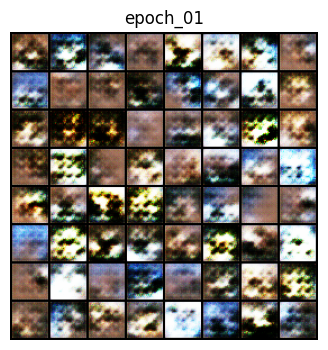

Epoch 02/10 | D: 0.557 | G: 2.444


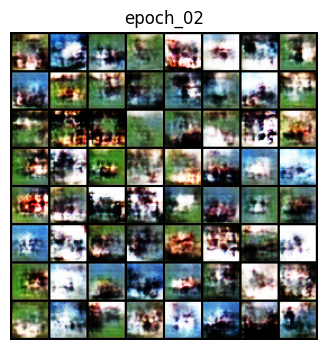

Epoch 03/10 | D: 0.288 | G: 2.306


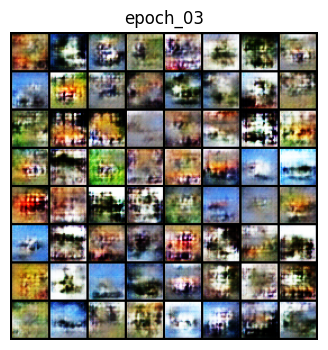

Epoch 04/10 | D: 0.458 | G: 2.594


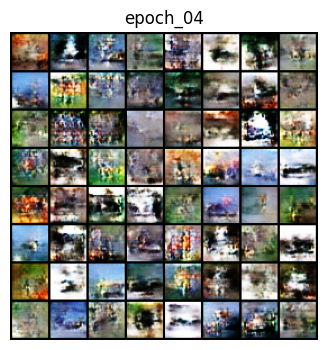

Epoch 05/10 | D: 0.619 | G: 3.557


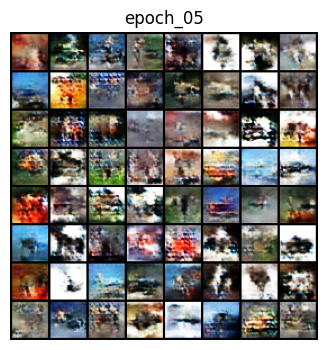

Epoch 06/10 | D: 0.648 | G: 1.928


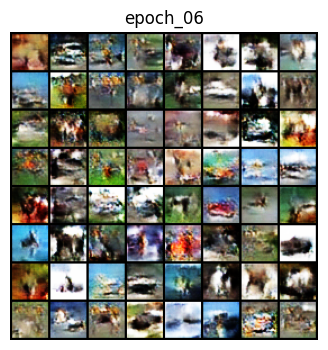

Epoch 07/10 | D: 0.444 | G: 1.754


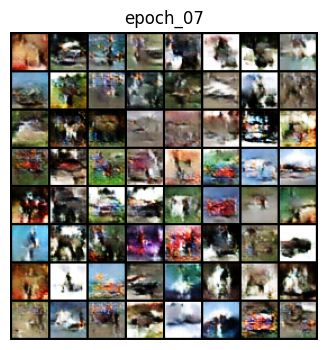

Epoch 08/10 | D: 0.598 | G: 2.160


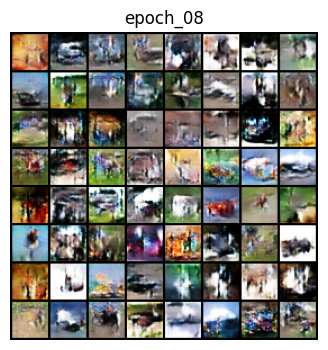

Epoch 09/10 | D: 0.709 | G: 1.752


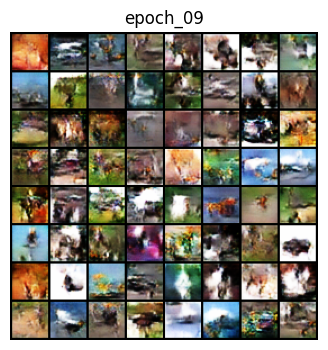

Epoch 10/10 | D: 0.872 | G: 2.102


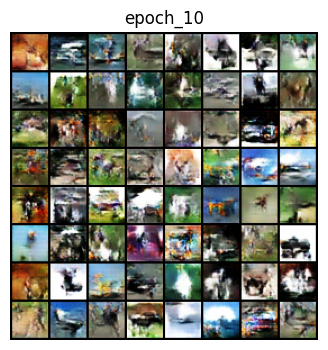

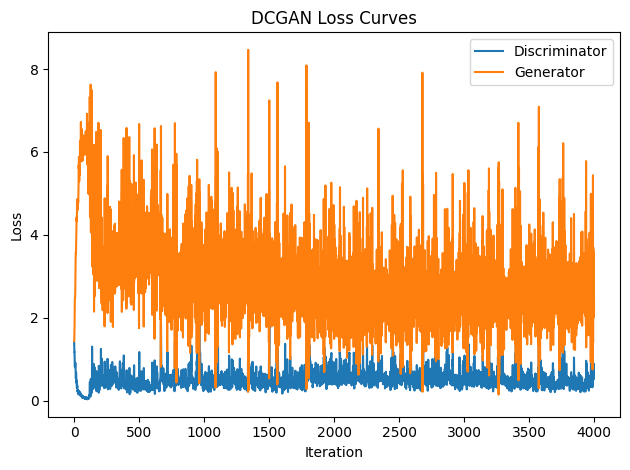

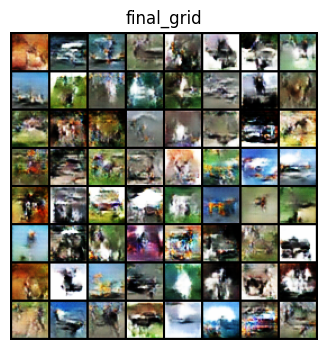


Short note:
Using the vanilla DCGAN (ReLU in G, BatchNorm in both) on CIFAR-10,
the generator began forming color blobs and coarse shapes around epochs 6–8,
with D and G losses oscillating but trending stable—indicating emerging structure/colors.


In [7]:
# ==== DCGAN Mini-Challenge (Win/CPU, ~3 min/epoch) ====
import os, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
import numpy as np

# Repro & device
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# -------- Runtime knobs (adjust to hit ~3 min/epoch on CPU) --------
BATCH_SIZE = 64
EPOCHS = 10
Z_DIM = 64
BASE = 64
MAX_BATCHES_PER_EPOCH = 400   # 350–450 usually ~3 min/epoch on CPU; raise/lower as needed
SAVE_DIR = "dcgan_outputs"; os.makedirs(SAVE_DIR, exist_ok=True)

# -------- Data (CIFAR-10, RGB 32×32) --------
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
dataset = datasets.CIFAR10("data", train=True, download=True, transform=transform)
# Windows CPU: num_workers=0 is often fastest
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)

# -------- Models (vanilla DCGAN) --------
class Generator(nn.Module):
    # z: (bs, Z_DIM,1,1) -> (bs,3,32,32)
    def __init__(self, z=Z_DIM, base=BASE):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z, base*4, 4, 1, 0, bias=False),   # 1->4
            nn.BatchNorm2d(base*4), nn.ReLU(True),
            nn.ConvTranspose2d(base*4, base*2, 4, 2, 1, bias=False), # 4->8
            nn.BatchNorm2d(base*2), nn.ReLU(True),
            nn.ConvTranspose2d(base*2, base,   4, 2, 1, bias=False), # 8->16
            nn.BatchNorm2d(base),   nn.ReLU(True),
            nn.ConvTranspose2d(base, 3,         4, 2, 1, bias=False),# 16->32
            nn.Tanh()
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    # returns logits
    def __init__(self, base=BASE):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, base,   4, 2, 1, bias=False),            # 32->16
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base, base*2, 4, 2, 1, bias=False),         # 16->8
            nn.BatchNorm2d(base*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base*2, base*4, 4, 2, 1, bias=False),       # 8->4
            nn.BatchNorm2d(base*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base*4, 1, 4, 1, 0, bias=False)             # 4->1
        )
    def forward(self, x): return self.net(x).view(-1)

G, D = Generator().to(device), Discriminator().to(device)

# -------- Optimizers & loss (standard DCGAN) --------
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

# Fixed noise for consistent 64-image grid
fixed_z = torch.randn(64, Z_DIM, 1, 1, device=device)

losses_G, losses_D = [], []

def preview(title):
    with torch.no_grad():
        samples = (G(fixed_z).cpu() + 1) / 2
        grid = utils.make_grid(samples, nrow=8)
    utils.save_image(grid, os.path.join(SAVE_DIR, f"{title.replace(' ','_')}.png"))
    plt.figure(figsize=(4,4)); plt.imshow(grid.permute(1,2,0)); plt.axis("off")
    plt.title(title); plt.show()

# -------- Train (10 epochs) --------
for epoch in range(1, EPOCHS+1):
    for i, (real, _) in enumerate(loader):
        if MAX_BATCHES_PER_EPOCH and i >= MAX_BATCHES_PER_EPOCH: break

        real = real.to(device)
        bsz  = real.size(0)
        y_real = torch.ones(bsz, device=device)
        y_fake = torch.zeros(bsz, device=device)

        # --- Train D ---
        z = torch.randn(bsz, Z_DIM, 1, 1, device=device)
        with torch.no_grad():
            fake = G(z)
        d_real = D(real)
        d_fake = D(fake)
        loss_D = criterion(d_real, y_real) + criterion(d_fake, y_fake)
        opt_D.zero_grad(set_to_none=True); loss_D.backward(); opt_D.step()

        # --- Train G ---
        z = torch.randn(bsz, Z_DIM, 1, 1, device=device)
        fake = G(z)
        loss_G = criterion(D(fake), y_real)  # want D(fake)=1
        opt_G.zero_grad(set_to_none=True); loss_G.backward(); opt_G.step()

        losses_D.append(loss_D.item()); losses_G.append(loss_G.item())

    print(f"Epoch {epoch:02d}/{EPOCHS} | D: {loss_D.item():.3f} | G: {loss_G.item():.3f}")
    preview(f"epoch_{epoch:02d}")

# -------- Curves --------
plt.figure(); plt.plot(losses_D, label="Discriminator"); plt.plot(losses_G, label="Generator")
plt.legend(); plt.xlabel("Iteration"); plt.ylabel("Loss"); plt.title("DCGAN Loss Curves")
plt.tight_layout(); plt.show()

# -------- Final 64-image grid --------
preview("final_grid")

# -------- Short note (3 lines) --------
print("\nShort note:")
print("Using the vanilla DCGAN (ReLU in G, BatchNorm in both) on CIFAR-10,")
print("the generator began forming color blobs and coarse shapes around epochs 6–8,")
print("with D and G losses oscillating but trending stable—indicating emerging structure/colors.")


Notes / Key Takeaways

DCGAN replaces dense layers with convs → spatial awareness.

Strided & transposed convs control image scaling.

BatchNorm + LeakyReLU = stability.

Use betas=(0.5, 0.999) for Adam (empirically stabilizes GANs).

Visual inspection is key — quantitative metrics (FID) come later.

Reflection

How does convolution improve sample quality vs MLP GAN?

Why is balancing D and G critical for stable DCGAN training?

1. How does convolution improve sample quality vs MLP GAN?
Convolutions preserve spatial structure in images — nearby pixels share features through local receptive fields. This lets the generator create coherent textures and shapes, and helps the discriminator focus on local image patterns. MLPs flatten everything, losing spatial context, which makes their samples blurry or noisy.

2. Why is balancing D and G critical for stable DCGAN training?
If the discriminator learns too fast, the generator’s gradients vanish (it can’t improve); if the generator dominates, D can’t guide learning. Keeping them balanced ensures steady adversarial feedback — D provides useful gradients, and G gradually learns to produce realistic images without collapsing.